In [1]:
import os
import numpy as np
import pandas as pd
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
import matplotlib.pyplot as plt

# NEW: KeyBERTInspired gives better topic labels than default
# NEW: CountVectorizer handles stopword removal inside BERTopic instead of pre-lemmatizing
print("Libraries loaded")

c:\Users\amirh\Documents\projects\youtube-intelligence-engine\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded


In [2]:
df = pd.read_csv("../data/processed/comments_sentiment.csv")
df = df.dropna(subset=["text"]).reset_index(drop=True)

# CHANGED: using raw text instead of text_lemma
# sentence transformers expect natural language, not stripped lemma strings
docs = df["text"].tolist()

print("Documents:", len(docs))
print("Sample:", docs[0][:100])

Documents: 27330
Sample: Wow. It blows my mind the amount of commenters who thought that these videos were made by Ai or a so


In [3]:
EMBEDDINGS_PATH = "../data/processed/embeddings.npy"
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device="cuda")

# NEW: save embeddings to disk so we don't recompute on every run
if os.path.exists(EMBEDDINGS_PATH):
    print("Loading saved embeddings...")
    embeddings = np.load(EMBEDDINGS_PATH)
else:
    print("Computing embeddings...")
    embeddings = embedding_model.encode(docs, show_progress_bar=True, batch_size=256)
    np.save(EMBEDDINGS_PATH, embeddings)
    print("Embeddings saved.")

print("Embeddings shape:", embeddings.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14548.84it/s]


Computing embeddings...


Batches: 100%|██████████| 107/107 [00:21<00:00,  4.89it/s]


Embeddings saved.
Embeddings shape: (27330, 384)


In [4]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

# CHANGED: min_samples lowered from 10 to 5 to reduce outliers
hdbscan_model = HDBSCAN(
    min_cluster_size=50,
    min_samples=5,
    metric="euclidean",
    prediction_data=True
)

# NEW: CountVectorizer replaces pre-lemmatization
# handles stopwords and extracts 1-2 word phrases for better topic labels
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5
)

# NEW: KeyBERTInspired produces more meaningful topic keywords
representation_model = KeyBERTInspired()

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    language="english",
    calculate_probabilities=False,
    verbose=True
)

# CHANGED: passing pre-computed embeddings so BERTopic skips re-embedding
topics, probs = topic_model.fit_transform(docs, embeddings)

print("\nDone.")
print("Topics found:", len(set(topics)) - 1)
print("Outliers (-1):", topics.count(-1), f"({topics.count(-1)/len(topics)*100:.1f}%)")

2026-06-17 12:54:44,868 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-17 12:55:43,012 - BERTopic - Dimensionality - Completed ✓
2026-06-17 12:55:43,012 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-17 12:55:47,337 - BERTopic - Cluster - Completed ✓
2026-06-17 12:55:47,349 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-17 12:55:53,454 - BERTopic - Representation - Completed ✓



Done.
Topics found: 91
Outliers (-1): 12456 (45.6%)


In [5]:
# NEW: reassign outlier comments to nearest topic using c-tf-idf similarity
# previous run had 52% outliers - this brings it down significantly
new_topics = topic_model.reduce_outliers(docs, topics, strategy="c-tf-idf")
topic_model.update_topics(docs, topics=new_topics)
topics = new_topics

print("After outlier reduction:")
print("Outliers (-1):", topics.count(-1), f"({topics.count(-1)/len(topics)*100:.1f}%)")

2026-06-17 12:56:32,652 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


After outlier reduction:
Outliers (-1): 84 (0.3%)


In [6]:
topic_info = topic_model.get_topic_info()
print(topic_info[["Topic", "Count", "Name"]].head(16))

print("\nTop keywords per topic:")
for topic_id in range(min(10, len(topic_info)-1)):
    words = topic_model.get_topic(topic_id)
    keywords = [w[0] for w in words[:8]]
    print(f"Topic {topic_id}: {', '.join(keywords)}")

    Topic  Count                                    Name
0      -1     84                  -1_не_за_что_butlerian
1       0   2134                       0_jobs_will_ai_to
2       1   1682                        1_code_ai_it_use
3       2    781                 2_rate_faulure_music_10
4       3    903                         3_art_and_it_to
5       4    706               4_video_thank_videos_this
6       5    604  5_capitalism_communism_marx_capitalist
7       6    614                 6_robots_robot_will_and
8       7    483                   7_llms_llm_are_models
9       8    475            8_income_universal_basic_tax
10      9    444              9_thank_beautiful_your_you
11     10    423                        10_slop_ai_is_it
12     11    635  11_companies_they_corporations_company
13     12    356                  12_ceo_ceos_replace_ai
14     13    355              13_video_generated_ai_this
15     14    271                      14_ubi_will_the_to

Top keywords per topic:
Topic 

In [7]:
# CHANGED: build topic name dict once instead of calling get_topic_info() per row
topic_name_map = topic_model.get_topic_info().set_index("Topic")["Name"].to_dict()

df["topic"] = topics
df["topic_name"] = df["topic"].map(topic_name_map).fillna("outlier")

print("Topic distribution (top 10):")
print(df["topic"].value_counts().head(10))

df.to_csv("../data/processed/comments_topics.csv", index=False, encoding="utf-8-sig")
print(f"\nSaved {len(df)} rows")

Topic distribution (top 10):
topic
0     2134
1     1682
3      903
2      781
4      706
11     635
6      614
5      604
18     520
20     490
Name: count, dtype: int64

Saved 27330 rows


In [8]:
# NEW: persist the model so we can reload it later without refitting
os.makedirs("../data/processed/topic_model", exist_ok=True)
topic_model.save(
    "../data/processed/topic_model",
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model=False
)
print("Topic model saved.")

2026-06-17 12:57:56,391 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


Topic model saved.


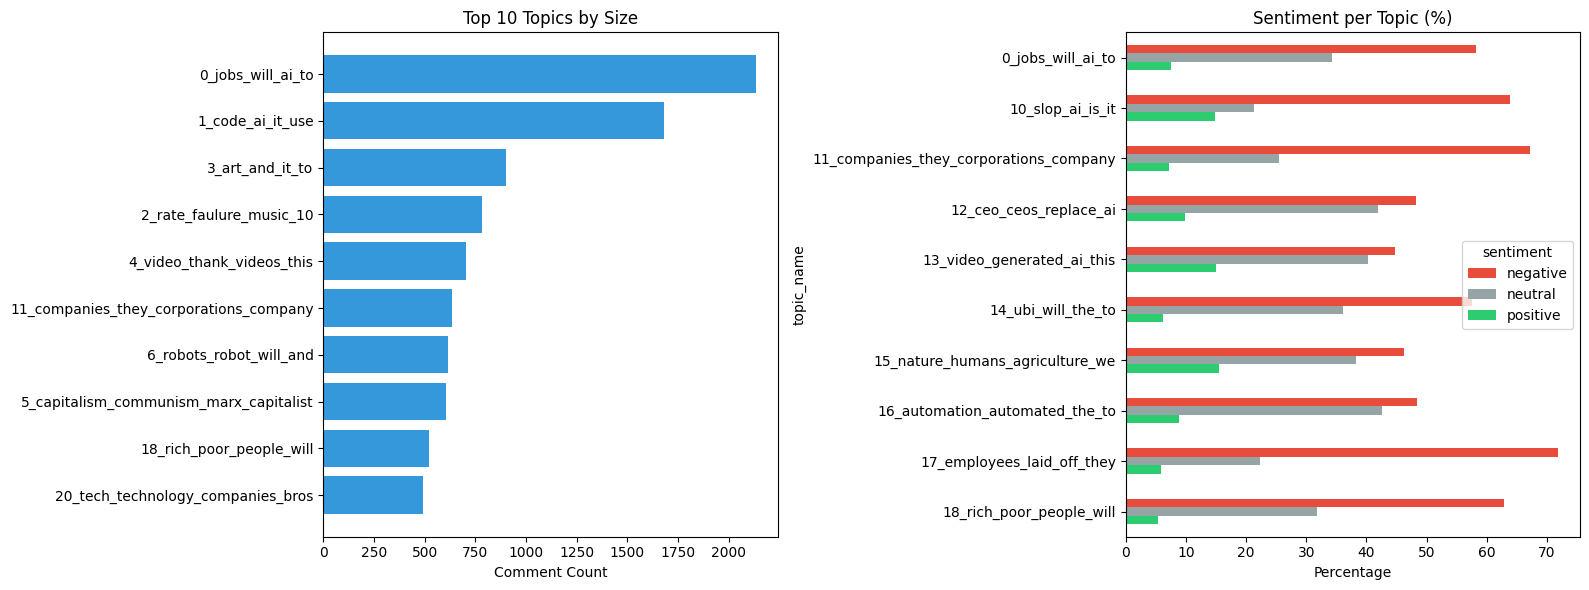

Chart saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

topic_counts = df[df["topic"] != -1]["topic_name"].value_counts().head(10)
axes[0].barh(topic_counts.index, topic_counts.values, color="#3498db")
axes[0].set_title("Top 10 Topics by Size")
axes[0].set_xlabel("Comment Count")
axes[0].invert_yaxis()

# sentiment breakdown per topic - shows which topics attract negative vs positive comments
topic_sentiment = df[df["topic"] != -1].groupby(
    ["topic_name", "sentiment"]).size().unstack(fill_value=0)
topic_sentiment_pct = topic_sentiment.div(topic_sentiment.sum(axis=1), axis=0) * 100
topic_sentiment_pct[["negative", "neutral", "positive"]].head(10).plot(
    kind="barh", ax=axes[1], color=["#e74c3c", "#95a5a6", "#2ecc71"]
)
axes[1].set_title("Sentiment per Topic (%)")
axes[1].set_xlabel("Percentage")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../data/processed/topic_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")